# Summarizer prompt A/B test

Same running summary strategy, two prompts. The only difference: one line telling the summarizer to tag facts with turn numbers.

1. **Prompt A** — "compress into bullet points, keep names and numbers"
2. **Prompt B** — same, plus "prefix each bullet with its turn number"

Takeaway: the architecture is the easy part. The prompt inside the architecture is where the performance lives.

In [26]:
%%capture --no-stderr
%pip install --quiet -U langchain-core langgraph langchain-google-genai

In [27]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, RemoveMessage, AnyMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display
from typing import TypedDict, Annotated
import os, json, statistics, time, getpass

from helpers import score_answer, INPUT_COST, OUTPUT_COST

def _set_env(var):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f'{var}: ')

_set_env('GOOGLE_API_KEY')

In [28]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)

TOKEN_WINDOW = 1_400
SUMMARY_THRESHOLD = 6
N_RUNS = 5

---

## The two prompts

In [29]:
PROMPT_A = """Compress into bullet points. MAX {max_tok} tokens.
Keep exact names, numbers, percentages.

Prior summary:
{prev}

New messages:
{old_text}"""

PROMPT_B = """You are maintaining a rolling knowledge base. Merge the prior summary with the new messages below.

Rules:
- ALWAYS prefix each bullet with its Turn number: 'T1: ...', 'T3: ...'
- Keep exact names, numbers, percentages (e.g. Go 78.2%, CoreAgent, bbolt>=1.4)
- One bullet per fact, max 20 words each
- If a fact appears in both, keep the more detailed version
- MAX {max_tok} tokens total

Prior summary:
{prev}

New messages:
{old_text}"""

print("Prompt A: generic compression")
print("Prompt B: same + turn-number attribution")

Prompt A: generic compression
Prompt B: same + turn-number attribution


---

## The graph

Summarizer is a graph node, not a tool. The agent never decides whether to summarize — the graph does.

`should_summarize` checks message count after the LLM responds. If over threshold, compress for the next turn.

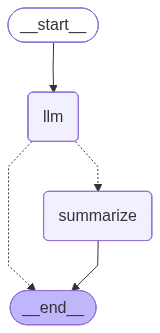

In [30]:
SYS_MSG = """You are a research assistant. You will be given facts about a fictional framework called AgentForge. Memorize each fact carefully. Later you will be quizzed.

AgentForge is entirely fictional. All answers MUST come from facts in this conversation.
Be precise: exact class names, exact numbers, exact percentages.
If a fact is not in your current context, say "I don't have that information in my current context."
"""

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    summary: str
    prompt_template: str


def token_count(msgs):
    return sum(len(m.content) // 3 for m in msgs if hasattr(m, 'content') and isinstance(m.content, str))


def call_llm(state: State):
    return {"messages": [llm.invoke([SystemMessage(content=SYS_MSG)] + state["messages"])]}


def should_summarize(state: State):
    if len(state["messages"]) > SUMMARY_THRESHOLD:
        return "summarize"
    return END


def summarize(state: State):
    msgs = state["messages"]
    keep_n = 4
    old, recent = msgs[:-keep_n], msgs[-keep_n:]

    old_text = "\n".join(f"{type(m).__name__}: {m.content[:500]}" for m in old if hasattr(m, 'content') and isinstance(m.content, str))
    max_tok = max(TOKEN_WINDOW // 3, 100)
    prev = state.get("summary", "")
    template = state.get("prompt_template", PROMPT_B)

    result = llm.invoke([HumanMessage(content=template.format(max_tok=max_tok, prev=prev, old_text=old_text))])
    removals = [RemoveMessage(id=m.id) for m in old if m.id]
    return {"summary": result.content, "messages": removals + [HumanMessage(content=f"[CONTEXT SUMMARY]\n{result.content}")]}


builder = StateGraph(State)
builder.add_node("llm", call_llm)
builder.add_node("summarize", summarize)
builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", should_summarize, {"summarize": "summarize", END: END})
builder.add_edge("summarize", END)
graph = builder.compile(checkpointer=InMemorySaver())

display(Image(graph.get_graph().draw_mermaid_png()))

---

## The task

30 turns on a fictional framework (AgentForge). T1-T10: learn facts. T11-T30: quizzed with increasing difficulty. Fictional so the model can't answer from training data.

In [31]:
TURNS = [
    {"id": 1, "question": "FACT (Turn 1): The AgentForge repository is written in Go 78.2% and Rust 21.8%. It has 4,312 stars and 1,847 commits on main. Acknowledge this fact.", "gt": "78.2", "type": "str"},
    {"id": 2, "question": "FACT (Turn 2): All AgentForge agents inherit from CoreAgent, which requires implementing `func (a *Agent) Execute(ctx RunContext) ([]Signal, error)`. Acknowledge this fact.", "gt": "CoreAgent", "type": "str"},
    {"id": 3, "question": "FACT (Turn 3): AgentForge has three workflow agent types: PipelineAgent (strict order), SwarmAgent (concurrent with ctx.Fork), and CycleAgent (loops until Halt=true). Acknowledge this fact.", "gt": "PipelineAgent", "type": "str"},
    {"id": 4, "question": "FACT (Turn 4): BridgeCapability enables agent-to-agent delegation. FuncCapability wraps Go functions as capabilities. Acknowledge this fact.", "gt": "BridgeCapability", "type": "str"},
    {"id": 5, "question": "FACT (Turn 5): AgentForge supports three session store backends: MemoryStore (default), BoltStore (persistent, requires bbolt>=1.4), and CloudSpannerStore (Google Cloud). Acknowledge this fact.", "gt": "MemoryStore", "type": "str"},
    {"id": 6, "question": "FACT (Turn 6): Third-party models use BridgeLLM adapter. Native Forge models: WithModel('forge-7b-fast'). Acknowledge this fact.", "gt": "BridgeLLM", "type": "str"},
    {"id": 7, "question": "FACT (Turn 7): The Conductor class orchestrates agent execution. Signal has Author, Content, Flags. IsFinalResponse() checks completion. Acknowledge this fact.", "gt": "Conductor", "type": "str"},
    {"id": 8, "question": "FACT (Turn 8): Setting OutputSpec on a TaskAgent disables both capability use and delegation. Acknowledge this fact.", "gt": "OutputSpec", "type": "str"},
    {"id": 9, "question": "FACT (Turn 9): Agent communication: shared session Vault, RouteToAgent via AutoRouter, and Hooks. Acknowledge this fact.", "gt": "Vault", "type": "str"},
    {"id": 10, "question": "FACT (Turn 10): Directives use {{var}}, {{state.var}}, null-safe {{var?}}. TuningConfig: Temperature, MaxTokens, NucleusP, BeamK. Acknowledge this fact.", "gt": "{{var}}", "type": "str"},
    # Phase 2: recent
    {"id": 11, "question": "Based on Turn 10, what is the null-safe template syntax?", "gt": "{{var?}}", "type": "str"},
    {"id": 12, "question": "Based on Turn 9, name the three agent communication mechanisms.", "gt": "Vault", "type": "str"},
    {"id": 13, "question": "Based on Turn 8, what does OutputSpec disable?", "gt": "disables", "type": "str"},
    {"id": 14, "question": "Based on Turn 7, what method checks Signal completion?", "gt": "IsFinalResponse", "type": "str"},
    {"id": 15, "question": "Using Turn 8 and 9: Can an OutputSpec agent use RouteToAgent?", "gt": "cannot", "type": "str"},
    {"id": 16, "question": "Using Turn 7 and 10: Configure Conductor with Temperature=0.2?", "gt": "Temperature", "type": "str"},
    # Phase 3: mid-range
    {"id": 17, "question": "Based on Turn 3, what happens when CycleAgent yields Halt=true?", "gt": "stop", "type": "str"},
    {"id": 18, "question": "Based on Turn 5, what dependency does BoltStore require?", "gt": "bbolt", "type": "str"},
    {"id": 19, "question": "Based on Turn 4, how does FuncCapability generate descriptions?", "gt": "doc comment", "type": "str"},
    {"id": 20, "question": "Based on Turn 6, how to use Claude 3 Haiku?", "gt": "bridgellm", "type": "str"},
    {"id": 21, "question": "Using Turn 4 and 8: Can BridgeCapability + OutputSpec coexist?", "gt": "cannot", "type": "str"},
    {"id": 22, "question": "Using Turn 3 and 9: Do SwarmAgent forked children share Vault?", "gt": "shared", "type": "str"},
    {"id": 23, "question": "Using Turn 5 and 7: What does BoltStore need that MemoryStore doesn't?", "gt": "bbolt", "type": "str"},
    # Phase 4: deep recall
    {"id": 24, "question": "Recall: exact fact from Turn 1 — language percentages and stats.", "gt": "78.2", "type": "str"},
    {"id": 25, "question": "Recall: exact fact from Turn 2 — base class and method.", "gt": "CoreAgent", "type": "str"},
    {"id": 26, "question": "Recall: exact fact from Turn 4 — both capability classes.", "gt": "BridgeCapability", "type": "str"},
    {"id": 27, "question": "Recall: exact fact from Turn 5 — all three session stores.", "gt": "CloudSpannerStore", "type": "str"},
    {"id": 28, "question": "Using Turn 1, 2, 6: language split, base class, and model adapter.", "gt": "BridgeLLM", "type": "str"},
    {"id": 29, "question": "Recall: Turn 3 and 6 — workflow agents and model adapter.", "gt": "CycleAgent", "type": "str"},
    {"id": 30, "question": "Final: Turn 1 (%), Turn 3 (agents), Turn 5 (stores), Turn 9 (comms).", "gt": "PipelineAgent", "type": "str"},
]
print(f"{len(TURNS)} turns: 10 facts, 6 recent, 7 mid-range, 7 deep recall")

30 turns: 10 facts, 6 recent, 7 mid-range, 7 deep recall


---

## Experiments

In [32]:
def run(name, template, n_runs=N_RUNS):
    print(f"\n{'='*50}\n {name} ({n_runs} runs)\n{'='*50}")
    all_runs = []
    for r in range(n_runs):
        print(f"\n--- run {r+1} ---")
        cfg = {"configurable": {"thread_id": f"{name}_{r}_{int(time.time())}"}}
        turns, seen = [], set()
        for t in TURNS:
            t0 = time.time()
            res = graph.invoke({"messages": [HumanMessage(content=t["question"])], "prompt_template": template}, cfg, version="v2")
            state = res.value
            answer = next((m.content if isinstance(m.content, str) else str(m.content) for m in reversed(state["messages"]) if isinstance(m, AIMessage) and m.content), None)
            sc = score_answer(answer, t["gt"], t["type"])
            inp = 0
            for m in state["messages"]:
                if isinstance(m, AIMessage) and getattr(m, "usage_metadata", None):
                    mid = getattr(m, 'id', id(m))
                    if mid not in seen:
                        seen.add(mid)
                        inp = max(inp, m.usage_metadata.get("input_tokens", 0))
            turns.append({"turn": t["id"], "score": sc, "input_tokens": inp, "duration_s": round(time.time()-t0, 2)})
            print(f"  T{t['id']:2d} {'\u2713' if sc >= 0.5 else '\u2717'} {sc:.1f}  {inp:>5d} tok")
        scores = [x["score"] for x in turns]
        all_runs.append({"turns": turns, "mean_score": statistics.mean(scores), "retention_score": scores[-1],
            "phase_scores": {"fact_injection": statistics.mean(scores[0:10]), "single_dep": statistics.mean(scores[10:16]),
                             "multi_dep": statistics.mean(scores[16:23]), "recall": statistics.mean(scores[23:30])}})
        print(f"  => acc={all_runs[-1]['mean_score']:.2f}  P4={all_runs[-1]['phase_scores']['recall']:.2f}")
    return all_runs

### Prompt A — no turn numbers

In [33]:
a_runs = run('prompt_A', PROMPT_A)


 prompt_A (5 runs)

--- run 1 ---
  T 1 ✓ 1.0    144 tok
  T 2 ✓ 1.0    237 tok
  T 3 ✓ 1.0    322 tok
  T 4 ✓ 1.0    394 tok
  T 5 ✓ 1.0    372 tok
  T 6 ✓ 1.0    413 tok
  T 7 ✓ 1.0    372 tok
  T 8 ✓ 1.0    430 tok
  T 9 ✓ 1.0    551 tok
  T10 ✓ 1.0    615 tok
  T11 ✓ 1.0    660 tok
  T12 ✓ 1.0    656 tok
  T13 ✓ 1.0    422 tok
  T14 ✗ 0.0    314 tok
  T15 ✗ 0.0    477 tok
  T16 ✗ 0.0    559 tok
  T17 ✓ 1.0    603 tok
  T18 ✓ 1.0    625 tok
  T19 ✗ 0.0    651 tok
  T20 ✗ 0.0    421 tok
  T21 ✗ 0.0    299 tok
  T22 ✗ 0.0    352 tok
  T23 ✓ 1.0    327 tok
  T24 ✗ 0.0    432 tok
  T25 ✗ 0.0    450 tok
  T26 ✓ 1.0    382 tok
  T27 ✓ 1.0    364 tok
  T28 ✗ 0.0    310 tok
  T29 ✗ 0.0    234 tok
  T30 ✗ 0.0    278 tok
  => acc=0.60  P4=0.29

--- run 2 ---
  T 1 ✓ 1.0    144 tok
  T 2 ✓ 1.0    237 tok
  T 3 ✓ 1.0    322 tok
  T 4 ✓ 1.0    394 tok
  T 5 ✓ 1.0    372 tok
  T 6 ✓ 1.0    413 tok
  T 7 ✓ 1.0    372 tok
  T 8 ✓ 1.0    430 tok
  T 9 ✓ 1.0    551 tok
  T10 ✓ 1.0    615 tok
  T11 ✓

### Prompt B — with turn numbers

In [34]:
b_runs = run('prompt_B', PROMPT_B)


 prompt_B (5 runs)

--- run 1 ---
  T 1 ✓ 1.0    144 tok
  T 2 ✓ 1.0    237 tok
  T 3 ✓ 1.0    322 tok
  T 4 ✓ 1.0    394 tok
  T 5 ✓ 1.0    383 tok
  T 6 ✓ 1.0    532 tok
  T 7 ✓ 1.0    646 tok
  T 8 ✓ 1.0    689 tok
  T 9 ✓ 1.0    739 tok
  T10 ✓ 1.0    804 tok
  T11 ✓ 1.0    862 tok
  T12 ✓ 1.0    900 tok
  T13 ✓ 1.0    943 tok
  T14 ✓ 1.0    978 tok
  T15 ✓ 1.0    990 tok
  T16 ✗ 0.0   1025 tok
  T17 ✗ 0.0   1047 tok
  T18 ✓ 1.0   1078 tok
  T19 ✗ 0.0   1120 tok
  T20 ✗ 0.0   1084 tok
  T21 ✓ 1.0   1048 tok
  T22 ✓ 1.0   1079 tok
  T23 ✓ 1.0   1158 tok
  T24 ✓ 1.0   1205 tok
  T25 ✓ 1.0   1272 tok
  T26 ✓ 1.0   1328 tok
  T27 ✓ 1.0   1302 tok
  T28 ✓ 1.0   1293 tok
  T29 ✓ 1.0   1313 tok
  T30 ✗ 0.0   1387 tok
  => acc=0.83  P4=0.86

--- run 2 ---
  T 1 ✓ 1.0    144 tok
  T 2 ✓ 1.0    237 tok
  T 3 ✓ 1.0    322 tok
  T 4 ✓ 1.0    394 tok
  T 5 ✓ 1.0    383 tok
  T 6 ✓ 1.0    532 tok
  T 7 ✓ 1.0    646 tok
  T 8 ✓ 1.0    689 tok
  T 9 ✓ 1.0    739 tok
  T10 ✓ 1.0    804 tok
  T11 ✓

---

## Results

In [35]:
import pandas as pd

def avg(runs, k): return statistics.mean([r[k] for r in runs])
def pavg(runs, k): return statistics.mean([r["phase_scores"][k] for r in runs])

pd.DataFrame([
    {"Prompt": "A (no turns)", "Accuracy": f"{avg(a_runs,'mean_score'):.2f}", "Retention": f"{avg(a_runs,'retention_score'):.2f}",
     "P2": f"{pavg(a_runs,'single_dep'):.2f}", "P3": f"{pavg(a_runs,'multi_dep'):.2f}", "P4 Recall": f"{pavg(a_runs,'recall'):.2f}"},
    {"Prompt": "B (with turns)", "Accuracy": f"{avg(b_runs,'mean_score'):.2f}", "Retention": f"{avg(b_runs,'retention_score'):.2f}",
     "P2": f"{pavg(b_runs,'single_dep'):.2f}", "P3": f"{pavg(b_runs,'multi_dep'):.2f}", "P4 Recall": f"{pavg(b_runs,'recall'):.2f}"},
])

,Prompt,Accuracy,Retention,P2,P3,P4 Recall
0,A (no turns),0.60,0.00,0.50,0.43,0.29
1,B (with turns),0.83,0.00,0.83,0.57,0.86


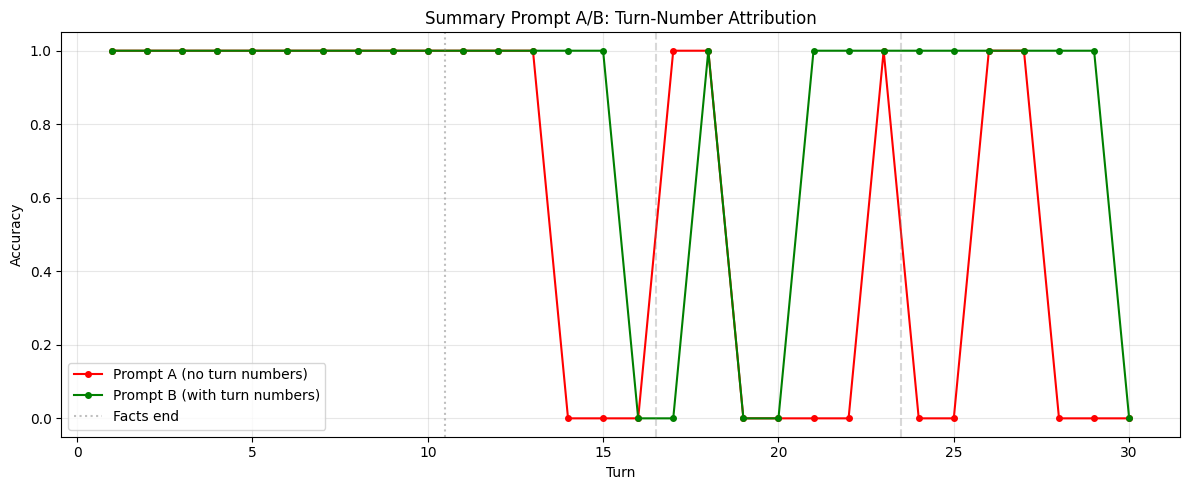

In [36]:
import matplotlib.pyplot as plt

a_avg = [statistics.mean([r["turns"][i]["score"] for r in a_runs]) for i in range(len(TURNS))]
b_avg = [statistics.mean([r["turns"][i]["score"] for r in b_runs]) for i in range(len(TURNS))]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(1, len(TURNS)+1)
ax.plot(x, a_avg, 'o-', color='red', label='Prompt A (no turn numbers)', markersize=4)
ax.plot(x, b_avg, 'o-', color='green', label='Prompt B (with turn numbers)', markersize=4)
ax.axvline(x=10.5, color='gray', linestyle=':', alpha=0.5, label='Facts end')
ax.axvline(x=16.5, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=23.5, color='gray', linestyle='--', alpha=0.3)
ax.set(xlabel='Turn', ylabel='Accuracy', title='Summary Prompt A/B: Turn-Number Attribution')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()